In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Preprocess data
# Reshape to (samples, height, width, channels)
x_train = x_train.reshape(-1, 32, 32, 3) / 255.0
x_test = x_test.reshape(-1, 32, 32, 3) / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

# Save the model
model.save("cifar_model.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 82ms/step - accuracy: 0.3592 - loss: 1.7737 - val_accuracy: 0.5206 - val_loss: 1.3598
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.5598 - loss: 1.2377 - val_accuracy: 0.6104 - val_loss: 1.1197
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 84ms/step - accuracy: 0.6254 - loss: 1.0731 - val_accuracy: 0.6392 - val_loss: 1.0538
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 80ms/step - accuracy: 0.6602 - loss: 0.9736 - val_accuracy: 0.6554 - val_loss: 1.0007
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.6870 - loss: 0.8977 - val_accuracy: 0.6742 - val_loss: 0.9548
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.7055 - loss: 0.8423 - val_accuracy: 0.6854 - val_loss: 0.9207
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 86ms/step - accuracy: 0.7386 - loss: 0.7577 - val_accuracy: 0.6898 - val_loss: 0.9222
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 80ms/step - accuracy: 0.7480 - loss: 0.7260 - 

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc*100:.2f}%")

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

fashion_model = load_model("cifar_model.h5")

sample_image = x_test[17].reshape(1,32,32,3)

prediction = fashion_model.predict(sample_image)

predicted_class = np.argmax(prediction)

print("Predicted:", predicted_class)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6898 - loss: 0.9364
Test accuracy: 68.94%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Predicted: 3


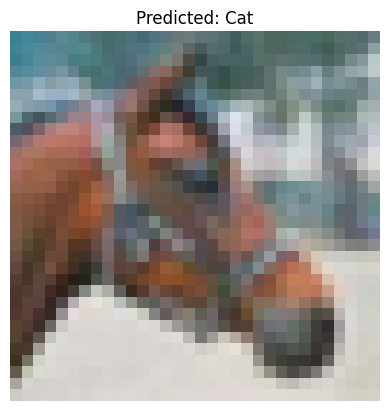

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


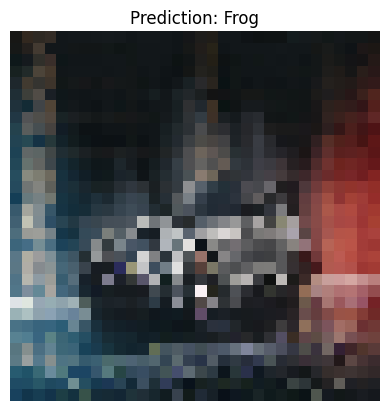

In [ ]:
# Display the sample image

plt.imshow(x_test[17]) # Remove reshape, as imshow handles (32,32,3) directly

plt.title(f"Predicted: {class_names[predicted_class]}")

plt.axis('off')

plt.show()

# Load PNG image

img = image.load_img(
    "mercedes-amg-gt-3840x2160-13596.jpg",
    target_size=(32, 32) # Change target_size to (32,32)
)
# Convert to array
img_array = image.img_to_array(img)
# Normalize and reshape
img_array = img_array / 255.0
img_array = img_array.reshape(1, 32, 32, 3) # Change reshape to (1,32,32,3)
# Predict
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction)
# Display result
plt.imshow(img) # Remove cmap='gray' as it's RGB
plt.title(f"Prediction: {class_names[predicted_digit]}")
plt.axis("off")
plt.show()